# Random Forest Regression (K-means Only)

This notebook keeps the K-means station cluster feature, removes encoding, and does not use scaling in the Random Forest model.

In [1]:
from __future__ import annotations

import math
from dataclasses import dataclass
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

TARGET_COL = "trips"
DEFAULT_FILE_PATH = "../data/processed/final_dataset.csv"


@dataclass
class KMeansArtifacts:
    cluster_map: dict[int, int]
    default_cluster: int
    station_profile_df: pd.DataFrame


def load_data(file_path: str = DEFAULT_FILE_PATH) -> pd.DataFrame:
    return pd.read_csv(file_path)


def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    return df.dropna().copy()


def split_data(df: pd.DataFrame, train_ratio: float = 0.8) -> tuple[pd.DataFrame, pd.DataFrame]:
    split_idx = int(len(df) * train_ratio)
    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()
    return train_df, test_df


def fit_station_kmeans(
    train_df: pd.DataFrame,
    n_clusters: int = 8,
    random_state: int = 42,
) -> KMeansArtifacts:
    profile_cols = [
        "lag_1",
        "lag_24",
        "member_ratio",
        "historical_avg_demand",
        TARGET_COL,
    ]
    station_profile_df = train_df.groupby("station_id")[profile_cols].mean()

    profile_means = station_profile_df.mean()
    profile_stds = station_profile_df.std().replace(0, 1)
    station_profile_norm = (station_profile_df - profile_means) / profile_stds

    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    station_profile_df = station_profile_df.copy()
    station_profile_df["station_cluster"] = kmeans.fit_predict(station_profile_norm)

    cluster_map = {int(idx): int(cluster) for idx, cluster in station_profile_df["station_cluster"].items()}
    default_cluster = int(station_profile_df["station_cluster"].mode().iloc[0])

    return KMeansArtifacts(
        cluster_map=cluster_map,
        default_cluster=default_cluster,
        station_profile_df=station_profile_df,
    )


def add_kmeans_feature(df: pd.DataFrame, artifacts: KMeansArtifacts) -> pd.DataFrame:
    out = df.copy()
    out["station_cluster"] = (
        out["station_id"]
        .map(artifacts.cluster_map)
        .fillna(artifacts.default_cluster)
        .astype(int)
    )
    out["is_weekend"] = out["is_weekend"].astype(int)
    return out


def prepare_features(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    feature_cols = [
        "station_id",
        "hour",
        "weekday",
        "month",
        "lag_1",
        "lag_24",
        "member_ratio",
        "is_weekend",
        "historical_avg_demand",
        "station_cluster",
    ]
    X = df[feature_cols].copy()
    y = df[TARGET_COL].copy()
    return X, y


def build_model(
    n_estimators: int = 80,
    max_depth: int | None = 20,
    min_samples_split: int = 5,
    min_samples_leaf: int = 2,
    max_features: str | float | int | None = "sqrt",
    random_state: int = 42,
    n_jobs: int = -1,
) -> RandomForestRegressor:
    return RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=random_state,
        n_jobs=n_jobs,
        bootstrap=True,
    )


def evaluate_model(model: RandomForestRegressor, X_test: pd.DataFrame, y_test: pd.Series) -> dict[str, Any]:
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = math.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "predictions": y_pred,
    }


def get_feature_importance(model: RandomForestRegressor, feature_names: list[str]) -> pd.DataFrame:
    importance_df = pd.DataFrame(
        {"feature": feature_names, "importance": model.feature_importances_}
    ).sort_values("importance", ascending=False, ignore_index=True)
    return importance_df


def run_experiment(
    file_path: str = DEFAULT_FILE_PATH,
    n_clusters: int = 8,
    **rf_kwargs: Any,
) -> dict[str, Any]:
    df = clean_data(load_data(file_path))
    train_df, test_df = split_data(df)

    kmeans_artifacts = fit_station_kmeans(train_df=train_df, n_clusters=n_clusters)
    train_df = add_kmeans_feature(train_df, kmeans_artifacts)
    test_df = add_kmeans_feature(test_df, kmeans_artifacts)

    X_train, y_train = prepare_features(train_df)
    X_test, y_test = prepare_features(test_df)

    model = build_model(**rf_kwargs)
    model.fit(X_train, y_train)

    results = evaluate_model(model, X_test, y_test)
    importance_df = get_feature_importance(model, X_train.columns.tolist())

    return {
        "model": model,
        "train_shape": X_train.shape,
        "test_shape": X_test.shape,
        "results": results,
        "importance_df": importance_df,
        "station_profiles": kmeans_artifacts.station_profile_df,
        "X_train_head": X_train.head(),
        "comparison_df": pd.DataFrame(
            {"actual": y_test.values, "predicted": results["predictions"]}
        ),
    }




In [ ]:
file_path = "../data/processed/final_dataset.csv"
experiment = run_experiment(file_path=file_path)
results = experiment["results"]
importance_df = experiment["importance_df"]
comparison_df = experiment["comparison_df"]

print("Random Forest Regression (K-means Only, No Encoding, No Scaling)")
print("Train shape:", experiment["train_shape"])
print("Test shape:", experiment["test_shape"])
print(f"MAE: {results['MAE']:.4f}")
print(f"MSE: {results['MSE']:.4f}")
print(f"RMSE: {results['RMSE']:.4f}")

Random Forest Regression (K-means Only, No Encoding, No Scaling)
Train shape: (929542, 10)
Test shape: (232386, 10)
MAE: 2.8002
MSE: 26.3976
RMSE: 5.1379
R2: 0.8525


In [3]:
experiment['X_train_head']

,station_id,hour,weekday,month,lag_1,lag_24,member_ratio,is_weekend,historical_avg_demand,station_cluster
24,7000,5,1,1,1.0,10.0,0.500000,0,49.68652,0
25,7000,6,1,1,4.0,6.0,0.052632,0,49.68652,0
26,7000,7,1,1,19.0,16.0,0.217391,0,49.68652,0
27,7000,8,1,1,23.0,19.0,0.211268,0,49.68652,0
28,7000,9,1,1,71.0,42.0,0.285714,0,49.68652,0


In [4]:
importance_df.head(15)

,feature,importance
0,lag_1,0.496290
1,lag_24,0.260343
2,hour,0.069102
3,historical_avg_demand,0.062088
4,member_ratio,0.050283
5,station_cluster,0.019415
6,month,0.017191
7,station_id,0.011595
8,weekday,0.010119
9,is_weekend,0.003574


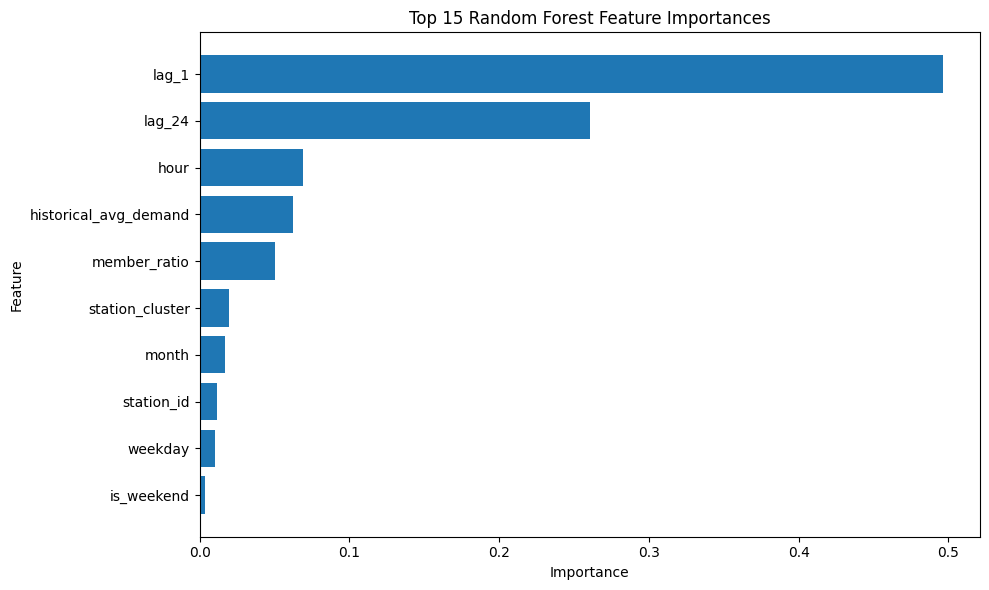

In [5]:
top_plot = importance_df.head(15).iloc[::-1]
plt.figure(figsize=(10, 6))
plt.barh(top_plot["feature"], top_plot["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

In [6]:
comparison_df.head(10)

,actual,predicted
0,3,6.953615
1,13,12.585591
2,11,20.811282
3,12,13.254743
4,7,15.349228
5,12,11.736330
6,14,10.120699
7,15,11.347084
8,13,17.333701
9,27,15.449593


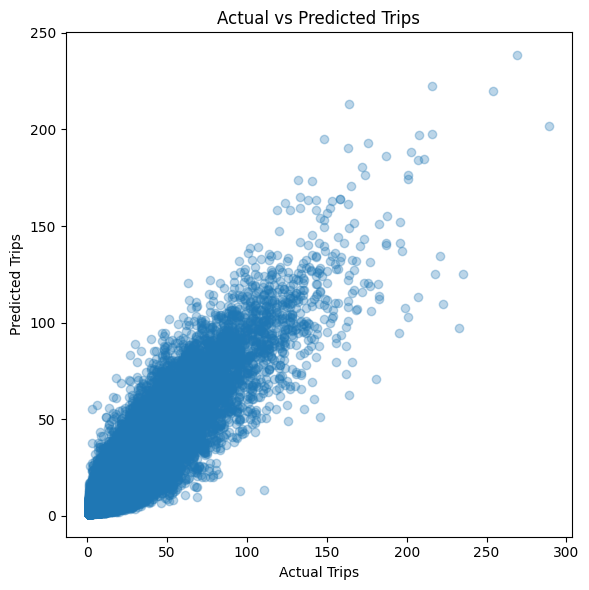

In [7]:
plt.figure(figsize=(6, 6))
plt.scatter(comparison_df["actual"], comparison_df["predicted"], alpha=0.3)
plt.xlabel("Actual Trips")
plt.ylabel("Predicted Trips")
plt.title("Actual vs Predicted Trips")
plt.tight_layout()
plt.show()

## Notes

- `station_cluster` is the K-means feature.
- No encoding is applied in this version.
- No scaling is used in the Random Forest model.
- `hour`, `weekday`, and `month` are kept in numeric form.
